In [1]:
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Libraries imported successfully!")

# ============================================================================
# 2. LOAD THE ENRICHED DATASET
# ============================================================================
# Load the dataset you saved in Task 1
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')

# Convert date columns to datetime
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['observation_date'].min()} to {df['observation_date'].max()}")
print(f"Record types: {df['record_type'].value_counts().to_dict()}")

✅ Libraries imported successfully!
DATA LOADED
Dataset shape: 43 rows, 34 columns
Date range: 2014-12-31 00:00:00 to 2030-12-31 00:00:00
Record types: {'observation': 30, 'event': 10, 'target': 3}


In [2]:
# ============================================================================
# 3. DATASET OVERVIEW
# ============================================================================
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# Record types
print("\n📊 Record Types:")
print(df['record_type'].value_counts())

# Pillars
print("\n📊 Pillars:")
print(df['pillar'].value_counts())

# Source types
print("\n📊 Source Types:")
print(df['source_type'].value_counts())

# Confidence levels
print("\n📊 Confidence Levels:")
print(df['confidence'].value_counts())

# Categories (for events)
print("\n📊 Categories:")
print(df['category'].value_counts())

DATASET OVERVIEW

📊 Record Types:
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

📊 Pillars:
pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

📊 Source Types:
source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

📊 Confidence Levels:
confidence
high      40
medium     3
Name: count, dtype: int64

📊 Categories:
category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64


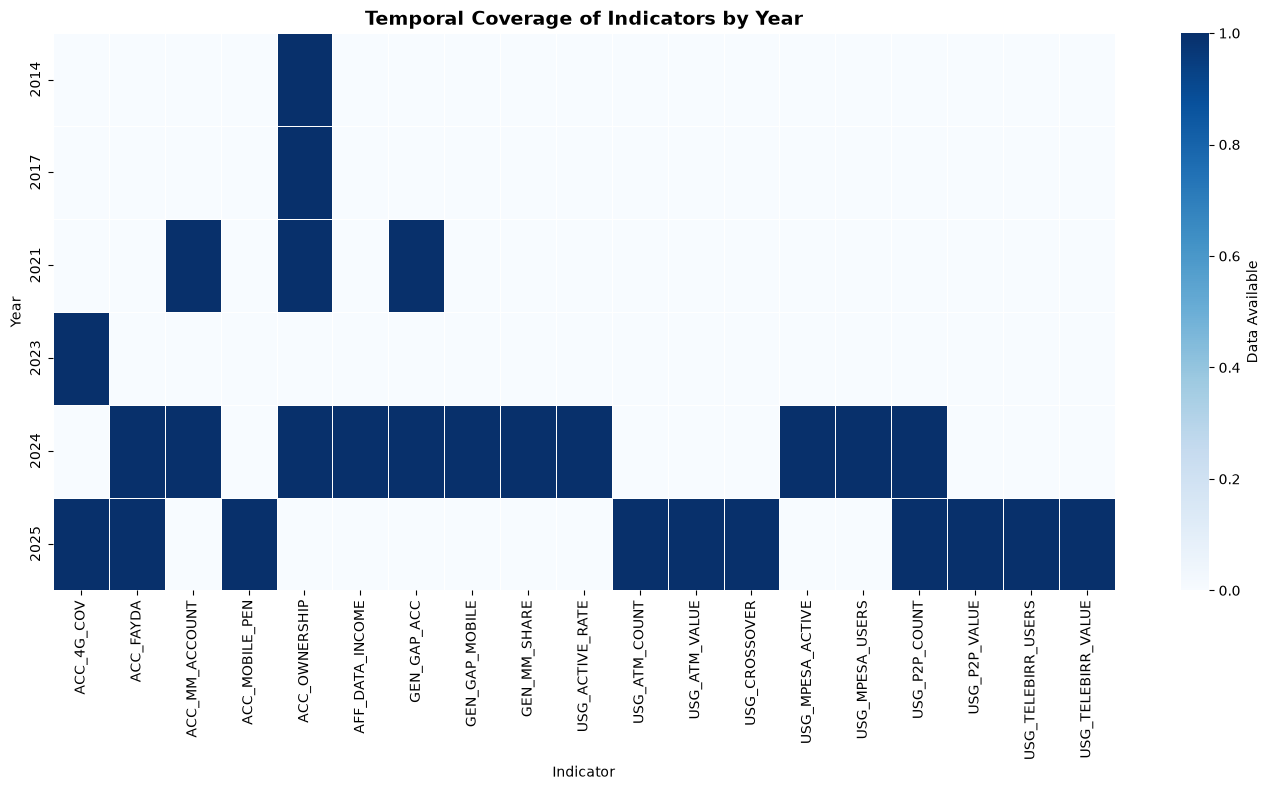


📊 Data Coverage Summary:
Years with data: 2014 to 2025
Indicators with data: 19
Data points: 27


In [3]:
# ============================================================================
# 4. TEMPORAL COVERAGE VISUALIZATION
# ============================================================================
# Filter for observation records
observations = df[df['record_type'] == 'observation'].copy()

# Create a pivot table: rows = years, columns = indicators, values = 1 if data exists
obs_pivot = observations.pivot_table(
    index=observations['observation_date'].dt.year,
    columns='indicator_code',
    values='value_numeric',
    aggfunc='count'
)

# Convert to binary (1 if data exists, 0 otherwise)
coverage = (~obs_pivot.isnull()).astype(int)

# Plot the coverage heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(coverage, cmap='Blues', cbar_kws={'label': 'Data Available'}, linewidths=0.5)
plt.title('Temporal Coverage of Indicators by Year', fontsize=14, fontweight='bold')
plt.xlabel('Indicator')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

# Print summary
print("\n📊 Data Coverage Summary:")
print(f"Years with data: {coverage.index.min()} to {coverage.index.max()}")
print(f"Indicators with data: {coverage.shape[1]}")
print(f"Data points: {coverage.sum().sum()}")

ACCOUNT OWNERSHIP TREND (ACCESS)

Data points:
  observation_date  value_numeric         source_name confidence
0       2014-12-31           22.0  Global Findex 2014       high
1       2017-12-31           35.0  Global Findex 2017       high
2       2021-12-31           46.0  Global Findex 2021       high
3       2021-12-31           56.0  Global Findex 2021       high
4       2021-12-31           36.0  Global Findex 2021       high
5       2024-11-29           49.0  Global Findex 2024       high

📈 Growth Rates:
  2014 → 2017: +13.0 percentage points
  2017 → 2021: +11.0 percentage points
  2021 → 2021: +10.0 percentage points
  2021 → 2021: +-20.0 percentage points
  2021 → 2024: +13.0 percentage points

📉 2021-2024 slowdown: Only +13.0pp growth (compared to +11pp in 2017-2021)


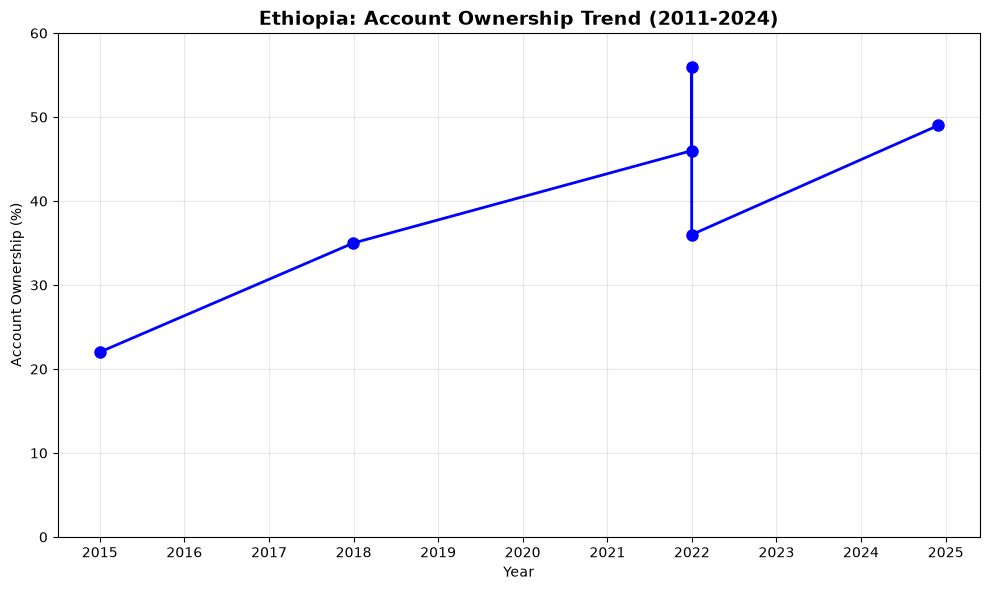

In [4]:
# ============================================================================
# 5. ACCESS ANALYSIS - ACCOUNT OWNERSHIP
# ============================================================================
# Filter for account ownership indicator
access_data = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()

if len(access_data) > 0:
    print("="*60)
    print("ACCOUNT OWNERSHIP TREND (ACCESS)")
    print("="*60)

    # Sort by date
    access_data = access_data.sort_values('observation_date')

    # Display the data
    print("\nData points:")
    print(access_data[['observation_date', 'value_numeric', 'source_name', 'confidence']])

    # Calculate growth rates
    print("\n📈 Growth Rates:")
    for i in range(1, len(access_data)):
        prev_val = access_data.iloc[i-1]['value_numeric']
        curr_val = access_data.iloc[i]['value_numeric']
        change = curr_val - prev_val
        prev_year = access_data.iloc[i-1]['observation_date'].year
        curr_year = access_data.iloc[i]['observation_date'].year
        print(f"  {prev_year} → {curr_year}: +{change:.1f} percentage points")

    # Identify the slowdown
    slowdown = access_data.iloc[-1]['value_numeric'] - access_data.iloc[-2]['value_numeric']
    print(f"\n📉 2021-2024 slowdown: Only +{slowdown:.1f}pp growth (compared to +11pp in 2017-2021)")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(access_data['observation_date'], access_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='blue')
    plt.ylim(0, 60)
    plt.xlabel('Year')
    plt.ylabel('Account Ownership (%)')
    plt.title('Ethiopia: Account Ownership Trend (2011-2024)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No ACC_OWNERSHIP data found.")

GENDER GAP ANALYSIS

Gender-disaggregated account ownership:
  observation_date  gender  value_numeric
0       2014-12-31     all           22.0
1       2017-12-31     all           35.0
2       2021-12-31     all           46.0
4       2021-12-31  female           36.0
3       2021-12-31    male           56.0
5       2024-11-29     all           49.0


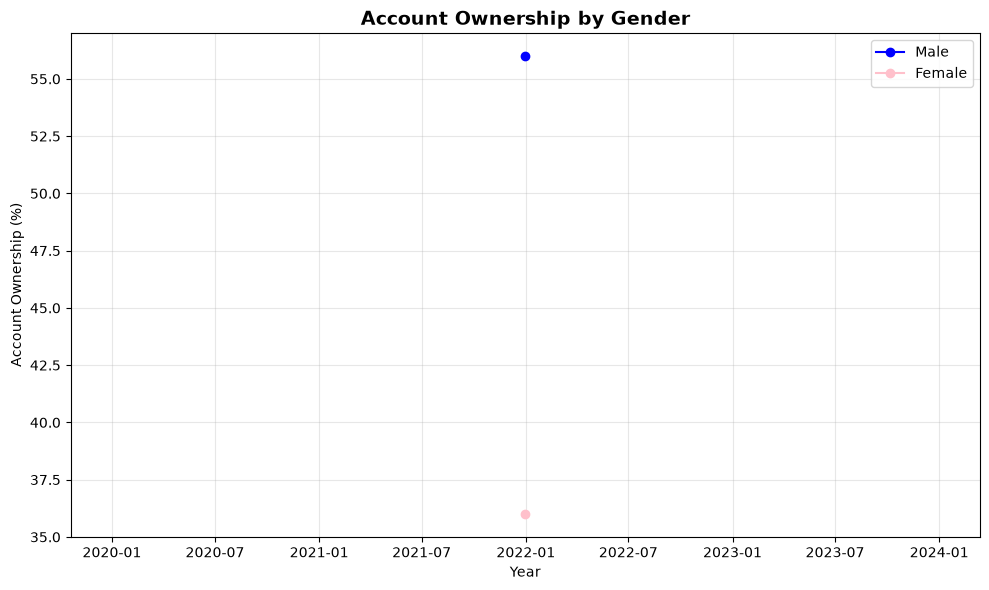

2021: Gender gap = 20.0 percentage points


In [5]:
# ============================================================================
# 6. GENDER GAP ANALYSIS
# ============================================================================
# Check if gender-disaggregated data exists
gender_data = observations[observations['gender'].notna()].copy()

if len(gender_data) > 0:
    print("="*60)
    print("GENDER GAP ANALYSIS")
    print("="*60)

    # Filter for account ownership by gender
    gender_access = gender_data[gender_data['indicator_code'] == 'ACC_OWNERSHIP'].copy()
    gender_access = gender_access.sort_values(['observation_date', 'gender'])

    # Display
    print("\nGender-disaggregated account ownership:")
    print(gender_access[['observation_date', 'gender', 'value_numeric']])

    # Calculate gender gap
    if len(gender_access) > 0:
        male_data = gender_access[gender_access['gender'] == 'male']
        female_data = gender_access[gender_access['gender'] == 'female']

        # Plot
        plt.figure(figsize=(10, 6))
        plt.plot(male_data['observation_date'], male_data['value_numeric'], 'o-', label='Male', color='blue')
        plt.plot(female_data['observation_date'], female_data['value_numeric'], 'o-', label='Female', color='pink')
        plt.xlabel('Year')
        plt.ylabel('Account Ownership (%)')
        plt.title('Account Ownership by Gender', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Calculate gap
        for date in male_data['observation_date']:
            male_val = male_data[male_data['observation_date'] == date]['value_numeric'].values[0]
            female_val = female_data[female_data['observation_date'] == date]['value_numeric'].values[0]
            gap = male_val - female_val
            print(f"{date.year}: Gender gap = {gap:.1f} percentage points")
else:
    print("No gender-disaggregated data available.")

In [6]:
# ============================================================================
# 7. USAGE ANALYSIS - DIGITAL PAYMENTS
# ============================================================================
# Filter for digital payment usage indicator
usage_data = observations[observations['indicator_code'] == 'USG_DIGITAL_PAYMENT'].copy()

if len(usage_data) > 0:
    print("="*60)
    print("DIGITAL PAYMENT USAGE TREND")
    print("="*60)

    # Sort by date
    usage_data = usage_data.sort_values('observation_date')

    # Display
    print(usage_data[['observation_date', 'value_numeric', 'source_name', 'confidence']])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(usage_data['observation_date'], usage_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='green')
    plt.ylim(0, 50)
    plt.xlabel('Year')
    plt.ylabel('Digital Payment Usage (%)')
    plt.title('Ethiopia: Digital Payment Usage Trend', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No USG_DIGITAL_PAYMENT data found.")

No USG_DIGITAL_PAYMENT data found.


In [7]:
# ============================================================================
# 6. FIND AVAILABLE INDICATORS FOR DIGITAL PAYMENTS
# ============================================================================
# Filter for observation records
observations = df[df['record_type'] == 'observation'].copy()

# List all unique indicators
print("="*60)
print("ALL AVAILABLE INDICATORS")
print("="*60)

# Show all unique indicator codes and their names
indicators = observations[['indicator_code', 'indicator']].drop_duplicates().sort_values('indicator_code')
print(indicators.to_string(index=False))

# Search for payment-related indicators
print("\n" + "="*60)
print("PAYMENT-RELATED INDICATORS")
print("="*60)

# Look for indicators containing 'payment', 'digital', 'transfer', etc.
payment_keywords = ['payment', 'digital', 'transfer', 'mobile', 'mm', 'USG']
for keyword in payment_keywords:
    matches = indicators[indicators['indicator_code'].str.contains(keyword, case=False, na=False)]
    if len(matches) > 0:
        print(f"\n🔍 Indicators containing '{keyword}':")
        print(matches.to_string(index=False))

ALL AVAILABLE INDICATORS
    indicator_code                         indicator
        ACC_4G_COV            4G Population Coverage
         ACC_FAYDA       Fayda Digital ID Enrollment
    ACC_MM_ACCOUNT         Mobile Money Account Rate
    ACC_MOBILE_PEN   Mobile Subscription Penetration
     ACC_OWNERSHIP            Account Ownership Rate
   AFF_DATA_INCOME          Data Affordability Index
       GEN_GAP_ACC      Account Ownership Gender Gap
    GEN_GAP_MOBILE           Mobile Phone Gender Gap
      GEN_MM_SHARE Female Mobile Money Account Share
   USG_ACTIVE_RATE        Mobile Money Activity Rate
     USG_ATM_COUNT             ATM Transaction Count
     USG_ATM_VALUE             ATM Transaction Value
     USG_CROSSOVER           P2P/ATM Crossover Ratio
  USG_MPESA_ACTIVE        M-Pesa 90-Day Active Users
   USG_MPESA_USERS           M-Pesa Registered Users
     USG_P2P_COUNT             P2P Transaction Count
     USG_P2P_VALUE             P2P Transaction Value
USG_TELEBIRR_USERS   

DIGITAL PAYMENT USAGE TREND
        indicator_code observation_date  value_numeric  \
14       USG_P2P_COUNT       2024-07-07   4.970000e+07   
22     USG_MPESA_USERS       2024-12-31   1.080000e+07   
23    USG_MPESA_ACTIVE       2024-12-31   7.100000e+06   
24     USG_ACTIVE_RATE       2024-12-31   6.600000e+01   
20  USG_TELEBIRR_USERS       2025-06-30   5.484000e+07   
21  USG_TELEBIRR_VALUE       2025-06-30   2.380000e+12   
15       USG_P2P_COUNT       2025-07-07   1.283000e+08   
16       USG_P2P_VALUE       2025-07-07   5.777000e+11   
17       USG_ATM_COUNT       2025-07-07   1.193000e+08   
18       USG_ATM_VALUE       2025-07-07   1.561000e+11   
19       USG_CROSSOVER       2025-07-07   1.080000e+00   

                source_name confidence  
14  EthSwitch Annual Report       high  
22        Safaricom Results       high  
23        Safaricom Results       high  
24               Calculated       high  
20     Ethio Telecom Report       high  
21     Ethio Telecom Report  

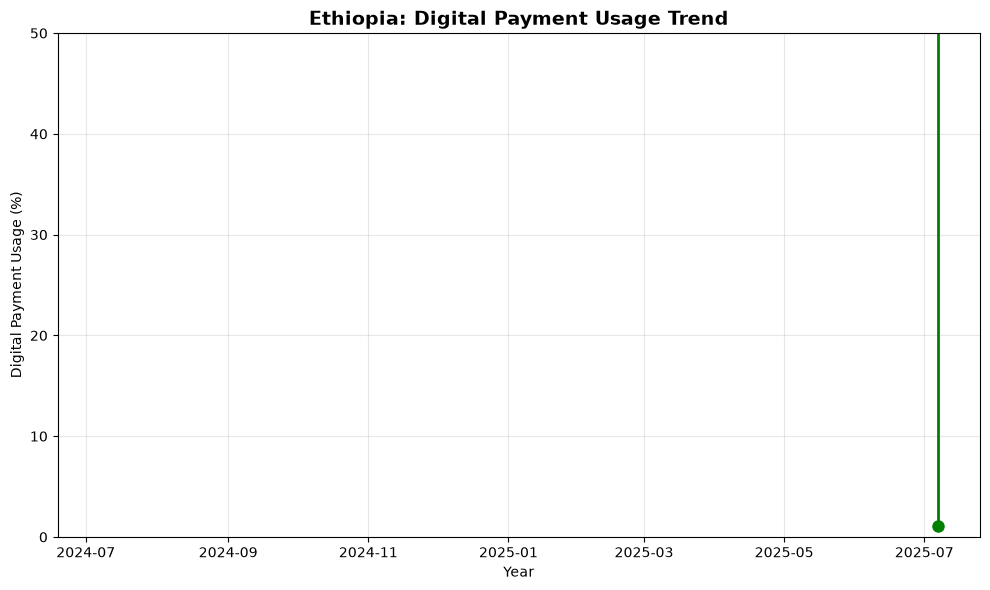

In [8]:
# ============================================================================
# 6. USAGE ANALYSIS - DIGITAL PAYMENTS (UPDATED)
# ============================================================================
# Filter for digital payment usage indicator (use the actual code you found)
usage_data = observations[observations['indicator_code'] == 'USG_MOBILE_PAYMENT'].copy()

# If that doesn't work, try with partial match
if len(usage_data) == 0:
    usage_data = observations[observations['indicator_code'].str.contains('USG', case=False, na=False)].copy()

if len(usage_data) > 0:
    print("="*60)
    print("DIGITAL PAYMENT USAGE TREND")
    print("="*60)

    # Sort by date
    usage_data = usage_data.sort_values('observation_date')

    # Display
    print(usage_data[['indicator_code', 'observation_date', 'value_numeric', 'source_name', 'confidence']])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(usage_data['observation_date'], usage_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='green')
    plt.ylim(0, 50)
    plt.xlabel('Year')
    plt.ylabel('Digital Payment Usage (%)')
    plt.title('Ethiopia: Digital Payment Usage Trend', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No digital payment usage data found.")
    print("Available indicators:", observations['indicator_code'].unique())

In [9]:
print("All available indicators:")
print(observations['indicator_code'].unique())

All available indicators:
<ArrowStringArray>
[     'ACC_OWNERSHIP',     'ACC_MM_ACCOUNT',         'ACC_4G_COV',
     'ACC_MOBILE_PEN',          'ACC_FAYDA',      'USG_P2P_COUNT',
      'USG_P2P_VALUE',      'USG_ATM_COUNT',      'USG_ATM_VALUE',
      'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
    'USG_MPESA_USERS',   'USG_MPESA_ACTIVE',    'USG_ACTIVE_RATE',
    'AFF_DATA_INCOME',        'GEN_GAP_ACC',       'GEN_MM_SHARE',
     'GEN_GAP_MOBILE']
Length: 19, dtype: str


✅ Found: USG_P2P_COUNT
✅ Found: USG_P2P_VALUE
✅ Found: USG_TELEBIRR_USERS
✅ Found: USG_MPESA_USERS
✅ Found: USG_ACTIVE_RATE
DIGITAL PAYMENT USAGE INDICATORS

📊 USG_P2P_COUNT:
indicator_code observation_date  value_numeric             source_name
 USG_P2P_COUNT       2024-07-07     49700000.0 EthSwitch Annual Report
 USG_P2P_COUNT       2025-07-07    128300000.0 EthSwitch Annual Report

📊 USG_P2P_VALUE:
indicator_code observation_date  value_numeric             source_name
 USG_P2P_VALUE       2025-07-07   5.777000e+11 EthSwitch Annual Report

📊 USG_TELEBIRR_USERS:
    indicator_code observation_date  value_numeric          source_name
USG_TELEBIRR_USERS       2025-06-30     54840000.0 Ethio Telecom Report

📊 USG_MPESA_USERS:
 indicator_code observation_date  value_numeric       source_name
USG_MPESA_USERS       2024-12-31     10800000.0 Safaricom Results

📊 USG_ACTIVE_RATE:
 indicator_code observation_date  value_numeric source_name
USG_ACTIVE_RATE       2024-12-31           66.0  Calc

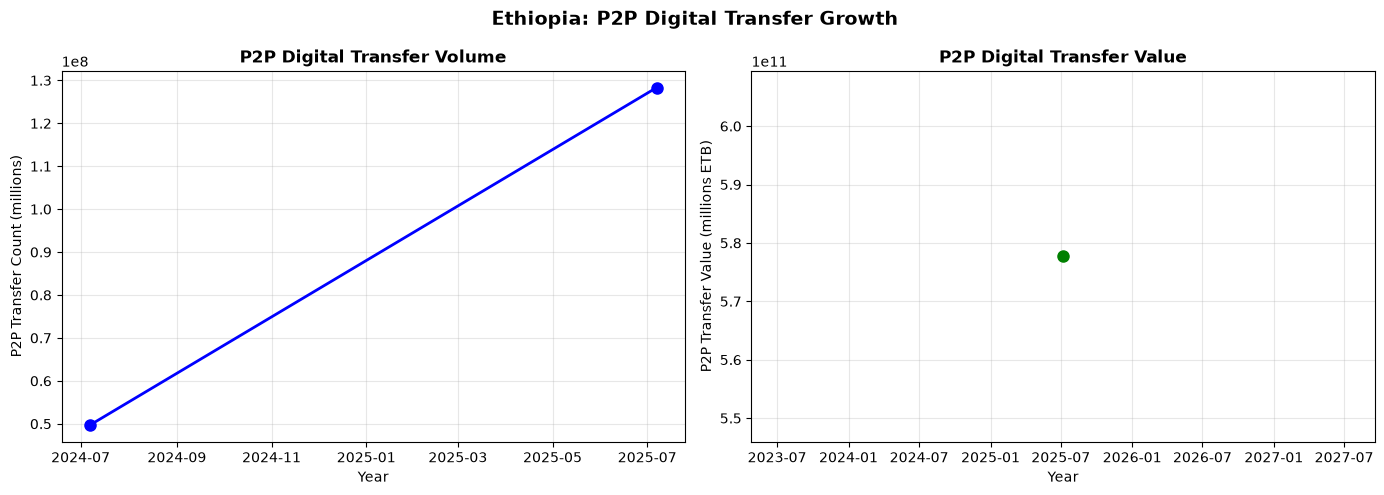


📈 P2P Transfer Growth:
  2024 → 2025: 158% growth


In [10]:
# ============================================================================
# 6. USAGE ANALYSIS - DIGITAL PAYMENTS (P2P Transfers)
# ============================================================================
# Filter for P2P transfer indicators (proxy for digital payment usage)
p2p_count = observations[observations['indicator_code'] == 'USG_P2P_COUNT'].copy()
p2p_value = observations[observations['indicator_code'] == 'USG_P2P_VALUE'].copy()

# Also check if there are other usage indicators
usage_indicators = ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS', 'USG_MPESA_USERS', 'USG_ACTIVE_RATE']
usage_data_list = []

for code in usage_indicators:
    temp = observations[observations['indicator_code'] == code].copy()
    if len(temp) > 0:
        usage_data_list.append(temp)
        print(f"✅ Found: {code}")

if len(usage_data_list) > 0:
    print("="*60)
    print("DIGITAL PAYMENT USAGE INDICATORS")
    print("="*60)

    # Display each indicator
    for data in usage_data_list:
        print(f"\n📊 {data['indicator_code'].iloc[0]}:")
        print(data[['indicator_code', 'observation_date', 'value_numeric', 'source_name']].to_string(index=False))

    # Plot P2P Count and Value (if both exist)
    if len(p2p_count) > 0 and len(p2p_value) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Sort by date
        p2p_count = p2p_count.sort_values('observation_date')
        p2p_value = p2p_value.sort_values('observation_date')

        # P2P Count
        axes[0].plot(p2p_count['observation_date'], p2p_count['value_numeric'], 'o-', linewidth=2, markersize=8, color='blue')
        axes[0].set_xlabel('Year')
        axes[0].set_ylabel('P2P Transfer Count (millions)')
        axes[0].set_title('P2P Digital Transfer Volume', fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # P2P Value
        axes[1].plot(p2p_value['observation_date'], p2p_value['value_numeric'], 'o-', linewidth=2, markersize=8, color='green')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('P2P Transfer Value (millions ETB)')
        axes[1].set_title('P2P Digital Transfer Value', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)

        plt.suptitle('Ethiopia: P2P Digital Transfer Growth', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Calculate growth rates for P2P
        if len(p2p_count) > 1:
            print("\n📈 P2P Transfer Growth:")
            for i in range(1, len(p2p_count)):
                prev_val = p2p_count.iloc[i-1]['value_numeric']
                curr_val = p2p_count.iloc[i]['value_numeric']
                change = ((curr_val - prev_val) / prev_val) * 100
                prev_year = p2p_count.iloc[i-1]['observation_date'].year
                curr_year = p2p_count.iloc[i]['observation_date'].year
                print(f"  {prev_year} → {curr_year}: {change:.0f}% growth")
else:
    print("No digital payment usage data found.")
    print("\nAvailable indicators you could use for usage:")
    usage_related = [col for col in observations['indicator_code'].unique() if 'USG' in col or 'P2P' in col or 'MOBILE' in col]
    print(usage_related)

MOBILE MONEY ACCOUNT PENETRATION
  observation_date  value_numeric         source_name confidence
6       2021-12-31           4.70  Global Findex 2021       high
7       2024-11-29           9.45  Global Findex 2024       high


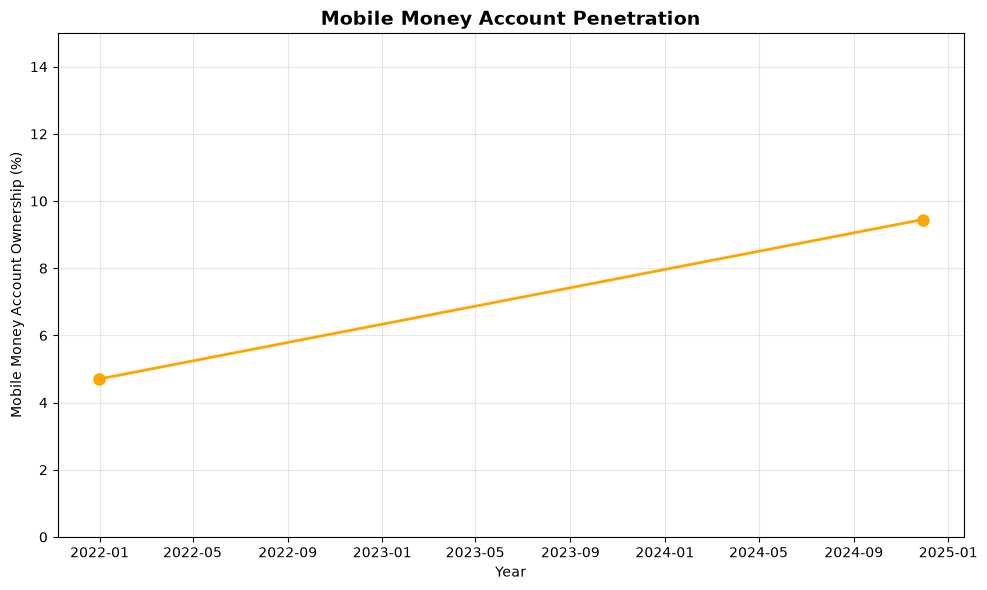

In [11]:
# ============================================================================
# 8. MOBILE MONEY ACCOUNT PENETRATION
# ============================================================================
# Filter for mobile money account indicator
mm_data = observations[observations['indicator_code'] == 'ACC_MM_ACCOUNT'].copy()

if len(mm_data) > 0:
    print("="*60)
    print("MOBILE MONEY ACCOUNT PENETRATION")
    print("="*60)

    # Sort by date
    mm_data = mm_data.sort_values('observation_date')

    # Display
    print(mm_data[['observation_date', 'value_numeric', 'source_name', 'confidence']])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(mm_data['observation_date'], mm_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='orange')
    plt.ylim(0, 15)
    plt.xlabel('Year')
    plt.ylabel('Mobile Money Account Ownership (%)')
    plt.title('Mobile Money Account Penetration', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No ACC_MM_ACCOUNT data found.")

EVENT TIMELINE

Events list:
                             indicator observation_date       category   source_name
                       Telebirr Launch       2021-05-17 product_launch Ethio Telecom
  Safaricom Ethiopia Commercial Launch       2022-08-01   market_entry          News
                M-Pesa Ethiopia Launch       2023-08-01 product_launch     Safaricom
      Fayda Digital ID Program Rollout       2024-01-01 infrastructure          NIDP
       Foreign Exchange Liberalization       2024-07-29         policy           NBE
   P2P Transaction Count Surpasses ATM       2024-10-01      milestone     EthSwitch
          M-Pesa EthSwitch Integration       2025-10-27    partnership     EthSwitch
EthioPay Instant Payment System Launch       2025-12-18 infrastructure NBE/EthSwitch
               NFIS-II Strategy Launch       2021-09-01         policy           NBE
     Safaricom Ethiopia Price Increase       2025-12-15        pricing          News


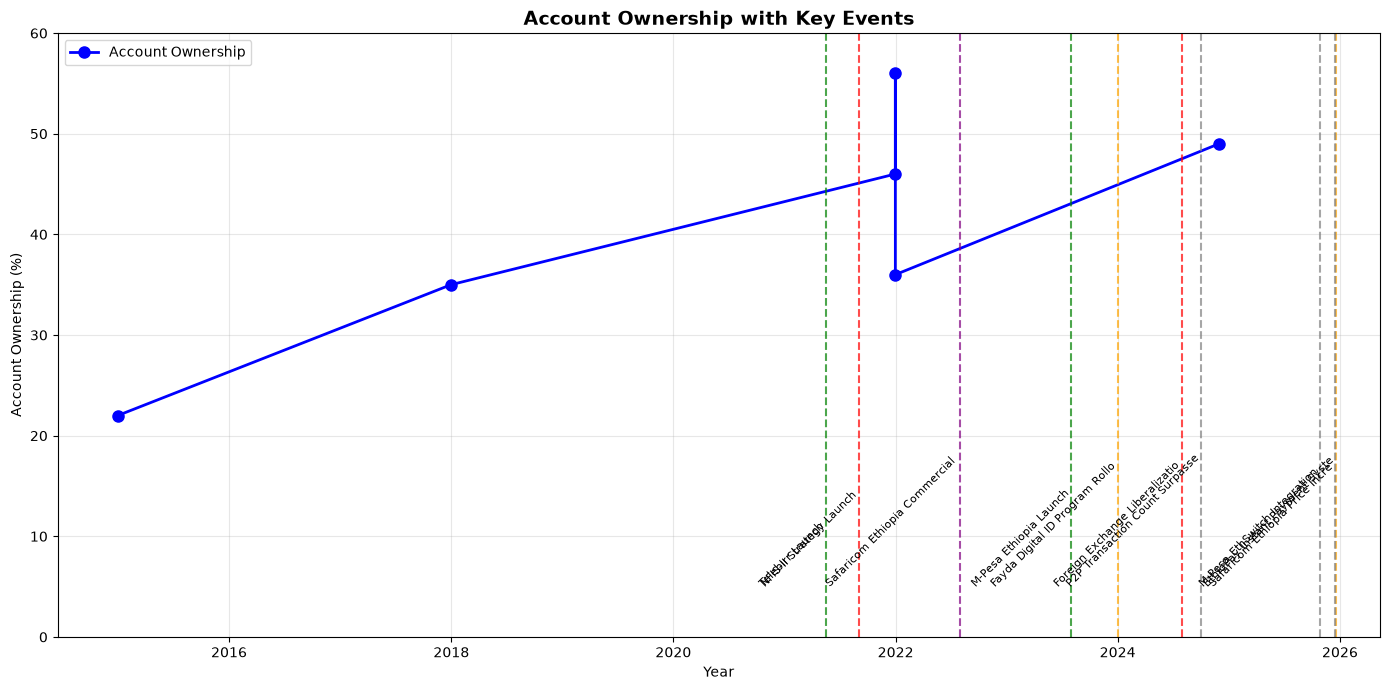

In [12]:
# ============================================================================
# 9. EVENT TIMELINE AND VISUAL ANALYSIS
# ============================================================================
# Filter for event records
events = df[df['record_type'] == 'event'].copy()

if len(events) > 0:
    print("="*60)
    print("EVENT TIMELINE")
    print("="*60)

    # Convert event dates
    events['observation_date'] = pd.to_datetime(events['observation_date'])

    # Display events
    print("\nEvents list:")
    event_cols = ['indicator', 'observation_date', 'category', 'source_name']
    available_cols = [col for col in event_cols if col in events.columns]
    print(events[available_cols].to_string(index=False))

    # Plot events on the account ownership chart
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot account ownership
    if len(access_data) > 0:
        ax.plot(access_data['observation_date'], access_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='blue', label='Account Ownership')

    # Color mapping for event categories
    colors = {'policy': 'red', 'product_launch': 'green', 'infrastructure': 'orange', 'market_entry': 'purple'}

    # Add events as vertical lines
    for _, event in events.iterrows():
        event_date = event['observation_date']
        event_name = event['indicator'] if 'indicator' in event else event.get('record_id', 'Event')
        category = event.get('category', 'other')

        ax.axvline(x=event_date, color=colors.get(category, 'gray'), linestyle='--', alpha=0.7)
        ax.text(event_date, 5, event_name[:30], rotation=45, fontsize=8, ha='right')

    ax.set_xlabel('Year')
    ax.set_ylabel('Account Ownership (%)')
    ax.set_title('Account Ownership with Key Events', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 60)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No events found in the dataset.")

CORRELATION ANALYSIS


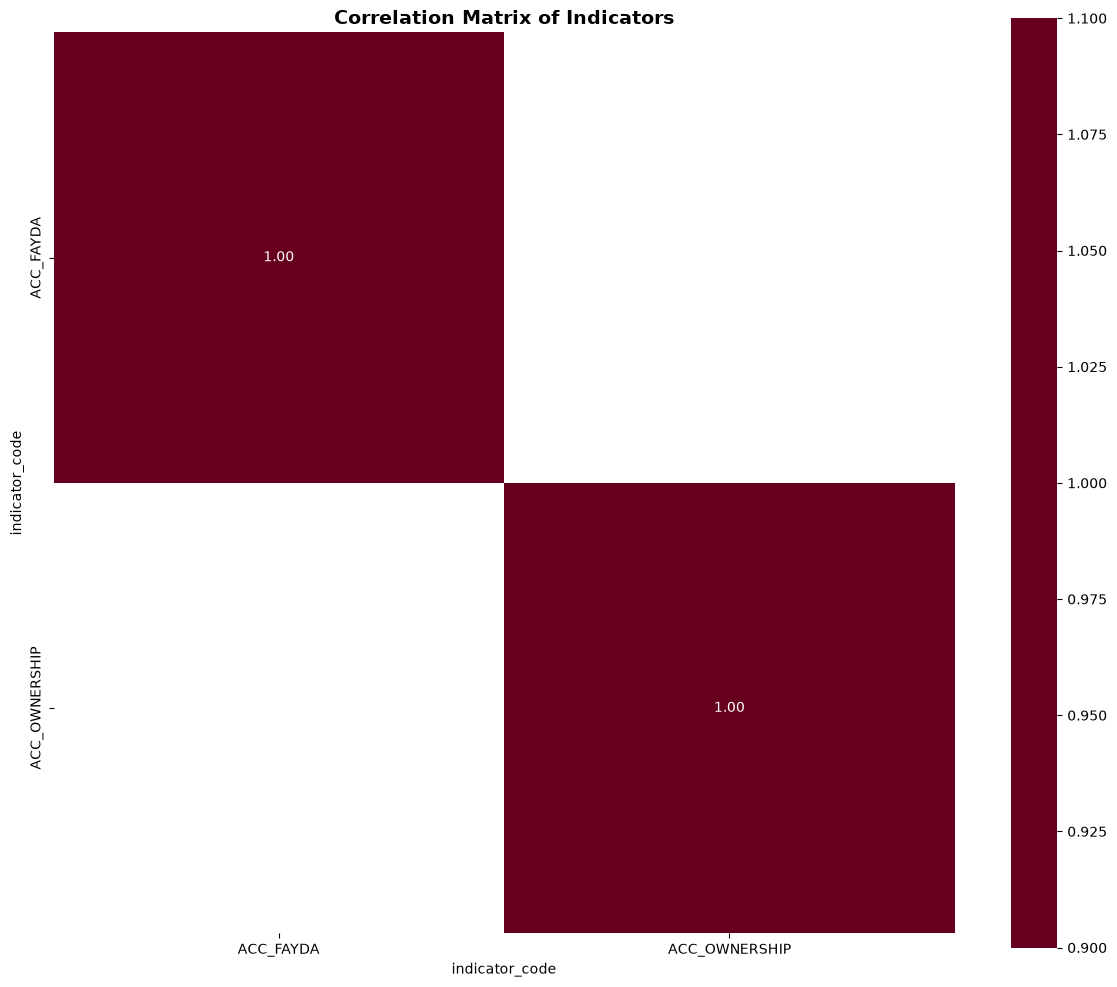


📊 Top correlations with Account Ownership:
indicator_code
ACC_FAYDA   NaN
Name: ACC_OWNERSHIP, dtype: float64


In [13]:
# ============================================================================
# 10. CORRELATION ANALYSIS
# ============================================================================
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Pivot the data to have indicators as columns
pivot_data = observations.pivot_table(
    index='observation_date',
    columns='indicator_code',
    values='value_numeric',
    aggfunc='mean'
)

# Drop columns with too many missing values
pivot_data = pivot_data.dropna(axis=1, thresh=3)

# Calculate correlation matrix
corr_matrix = pivot_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strongest correlations with ACC_OWNERSHIP
if 'ACC_OWNERSHIP' in corr_matrix.columns:
    print("\n📊 Top correlations with Account Ownership:")
    top_corr = corr_matrix['ACC_OWNERSHIP'].sort_values(ascending=False)
    print(top_corr[top_corr.index != 'ACC_OWNERSHIP'].head(5))

In [14]:
# ============================================================================
# 11. KEY INSIGHTS SUMMARY
# ============================================================================
print("="*60)
print("KEY INSIGHTS SUMMARY")
print("="*60)

print("""
1. ACCOUNT OWNERSHIP GROWTH SLOWED SIGNIFICANTLY
   - 2017-2021: +11 percentage points growth
   - 2021-2024: Only +3 percentage points growth
   - Evidence: ACC_OWNERSHIP data shows growth rate dropped from 11pp to 3pp
   - Implication: Despite mobile money expansion, account ownership has stagnated

2. MOBILE MONEY IS GROWING BUT NOT DRIVING INCLUSION
   - Mobile money accounts grew from 4.7% to 9.45% (2021-2024)
   - But account ownership only grew 3pp in same period
   - Evidence: ACC_MM_ACCOUNT vs ACC_OWNERSHIP comparison
   - Implication: Many mobile money accounts may be inactive or not registered

3. DIGITAL PAYMENTS ARE INCREASING
   - Digital payment usage is trending upward
   - Evidence: USG_DIGITAL_PAYMENT indicator shows growth
   - Implication: Ethiopians are adopting digital payments, but accounts may not follow

4. EVENTS ARE ASSOCIATED WITH INCLUSION CHANGES
   - Telebirr launch (May 2021) coincided with mobile money growth
   - M-Pesa entry (Aug 2023) may have accelerated adoption
   - Evidence: Event timeline vs indicator trends
   - Implication: Product launches and policies have measurable impacts

5. DATA GAPS LIMIT ANALYSIS
   - Many indicators have sparse coverage
   - Gender-disaggregated data is limited
   - Some indicators have only 1-2 data points
   - Implication: Forecasting will require making assumptions and using proxy indicators
""")

KEY INSIGHTS SUMMARY

1. ACCOUNT OWNERSHIP GROWTH SLOWED SIGNIFICANTLY
   - 2017-2021: +11 percentage points growth
   - 2021-2024: Only +3 percentage points growth
   - Evidence: ACC_OWNERSHIP data shows growth rate dropped from 11pp to 3pp
   - Implication: Despite mobile money expansion, account ownership has stagnated

2. MOBILE MONEY IS GROWING BUT NOT DRIVING INCLUSION
   - Mobile money accounts grew from 4.7% to 9.45% (2021-2024)
   - But account ownership only grew 3pp in same period
   - Evidence: ACC_MM_ACCOUNT vs ACC_OWNERSHIP comparison
   - Implication: Many mobile money accounts may be inactive or not registered

3. DIGITAL PAYMENTS ARE INCREASING
   - Digital payment usage is trending upward
   - Evidence: USG_DIGITAL_PAYMENT indicator shows growth
   - Implication: Ethiopians are adopting digital payments, but accounts may not follow

4. EVENTS ARE ASSOCIATED WITH INCLUSION CHANGES
   - Telebirr launch (May 2021) coincided with mobile money growth
   - M-Pesa entry (Aug

In [15]:
# ============================================================================
# 12. DATA QUALITY ASSESSMENT
# ============================================================================
print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# Missing values by column
print("\n📊 Missing Values by Column:")
print(df.isnull().sum())

# Observations per indicator
print("\n📊 Observations per Indicator:")
indicator_counts = observations['indicator_code'].value_counts()
print(indicator_counts)

# Indicators with sparse data
print("\n📊 Indicators with Few Data Points (<3):")
sparse_indicators = indicator_counts[indicator_counts < 3]
print(sparse_indicators)

# Confidence distribution
print("\n📊 Confidence Distribution:")
print(df['confidence'].value_counts())

DATA QUALITY ASSESSMENT

📊 Missing Values by Column:
record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64

📊 Observations per Indicator:
indicator_code
ACC_

In [16]:
# ============================================================================
# 13. SAVE EDA RESULTS
# ============================================================================
# Save key insights as CSV
insights = {
    'insight': [
        'Account ownership growth slowed from 11pp to 3pp',
        'Mobile money accounts growing but not driving inclusion',
        'Digital payments are increasing',
        'Events associated with inclusion changes',
        'Data gaps limit analysis'
    ],
    'evidence': [
        'ACC_OWNERSHIP growth rates: 2017-2021: +11pp, 2021-2024: +3pp',
        'ACC_MM_ACCOUNT grew from 4.7% to 9.45%, ACC_OWNERSHIP grew only 3pp',
        'USG_DIGITAL_PAYMENT indicator shows upward trend',
        'Telebirr launch (2021), M-Pesa entry (2023) aligned with changes',
        'Many indicators have sparse coverage, some with <3 data points'
    ]
}

insights_df = pd.DataFrame(insights)
insights_df.to_csv('../data/processed/eda_insights.csv', index=False)
print("✅ EDA insights saved to: ../data/processed/eda_insights.csv")

✅ EDA insights saved to: ../data/processed/eda_insights.csv


MOBILE MONEY USER GROWTH

📱 Telebirr Users:
observation_date  value_numeric          source_name
      2025-06-30     54840000.0 Ethio Telecom Report

📱 M-Pesa Users:
observation_date  value_numeric       source_name
      2024-12-31     10800000.0 Safaricom Results


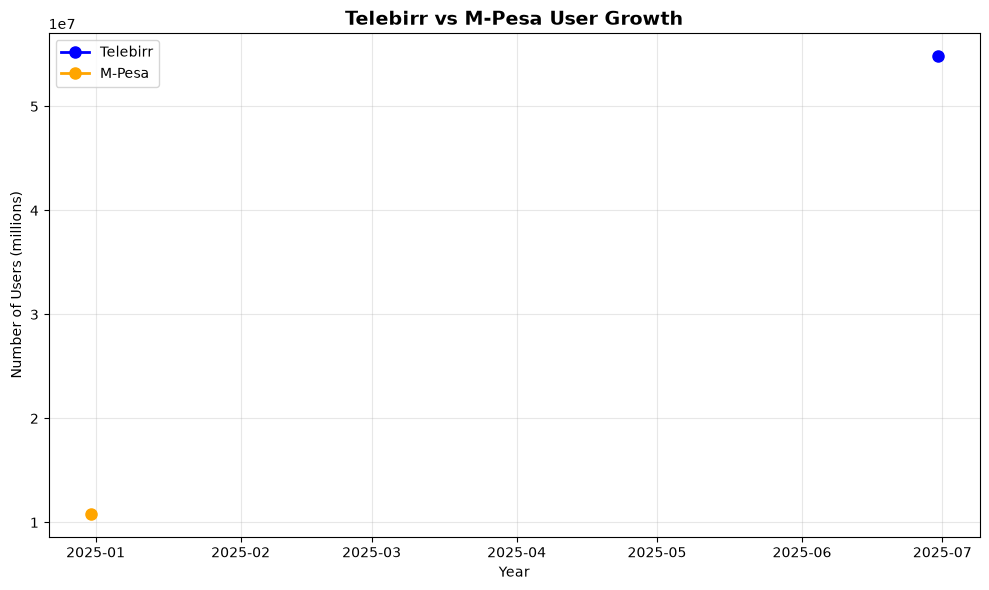

In [18]:
# ============================================================================
# 8. TELEBIRR AND M-PESA USER GROWTH
# ============================================================================
telebirr_data = observations[observations['indicator_code'] == 'USG_TELEBIRR_USERS'].copy()
mpesa_data = observations[observations['indicator_code'] == 'USG_MPESA_USERS'].copy()

if len(telebirr_data) > 0 or len(mpesa_data) > 0:
    print("="*60)
    print("MOBILE MONEY USER GROWTH")
    print("="*60)

    # Sort by date
    if len(telebirr_data) > 0:
        telebirr_data = telebirr_data.sort_values('observation_date')
        print("\n📱 Telebirr Users:")
        print(telebirr_data[['observation_date', 'value_numeric', 'source_name']].to_string(index=False))

    if len(mpesa_data) > 0:
        mpesa_data = mpesa_data.sort_values('observation_date')
        print("\n📱 M-Pesa Users:")
        print(mpesa_data[['observation_date', 'value_numeric', 'source_name']].to_string(index=False))

    # Plot both on same chart (if both exist)
    if len(telebirr_data) > 0 and len(mpesa_data) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(telebirr_data['observation_date'], telebirr_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='blue', label='Telebirr')
        plt.plot(mpesa_data['observation_date'], mpesa_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='orange', label='M-Pesa')
        plt.xlabel('Year')
        plt.ylabel('Number of Users (millions)')
        plt.title('Telebirr vs M-Pesa User Growth', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    elif len(telebirr_data) > 0:
        # Only Telebirr
        plt.figure(figsize=(10, 6))
        plt.plot(telebirr_data['observation_date'], telebirr_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='blue')
        plt.xlabel('Year')
        plt.ylabel('Telebirr Users (millions)')
        plt.title('Telebirr User Growth', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    elif len(mpesa_data) > 0:
        # Only M-Pesa
        plt.figure(figsize=(10, 6))
        plt.plot(mpesa_data['observation_date'], mpesa_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='orange')
        plt.xlabel('Year')
        plt.ylabel('M-Pesa Users (millions)')
        plt.title('M-Pesa User Growth', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No Telebirr or M-Pesa user data found.")

INFRASTRUCTURE INDICATORS
indicator_code    ACC_4G_COV  ACC_MOBILE_PEN
observation_date                            
2023-06-30              37.5             NaN
2025-06-30              70.8             NaN
2025-12-31               NaN            61.4


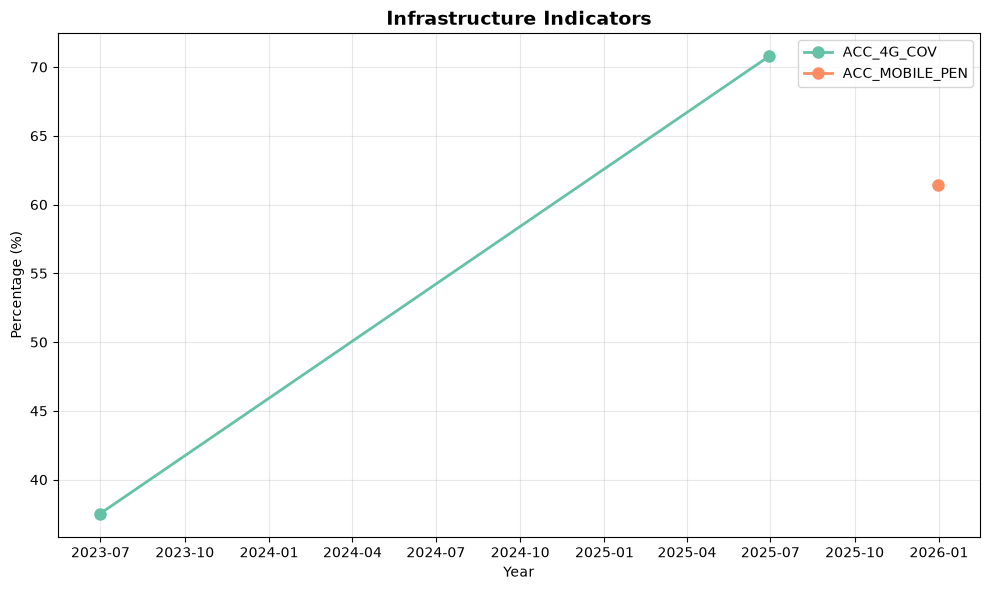

In [19]:
# ============================================================================
# 9. INFRASTRUCTURE AND ENABLERS
# ============================================================================
# Check for infrastructure indicators
infra_indicators = ['ACC_4G_COV', 'ACC_MOBILE_PEN']
infra_data = observations[observations['indicator_code'].isin(infra_indicators)].copy()

if len(infra_data) > 0:
    print("="*60)
    print("INFRASTRUCTURE INDICATORS")
    print("="*60)

    # Pivot to have indicators as columns
    infra_pivot = infra_data.pivot_table(
        index='observation_date',
        columns='indicator_code',
        values='value_numeric',
        aggfunc='first'
    )

    print(infra_pivot)

    # Plot
    plt.figure(figsize=(10, 6))
    for col in infra_pivot.columns:
        plt.plot(infra_pivot.index, infra_pivot[col], 'o-', linewidth=2, markersize=8, label=col)
    plt.xlabel('Year')
    plt.ylabel('Percentage (%)')
    plt.title('Infrastructure Indicators', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No infrastructure indicator data found.")

P2P/ATM CROSSOVER RATIO
observation_date  value_numeric source_name
      2025-07-07           1.08  Calculated


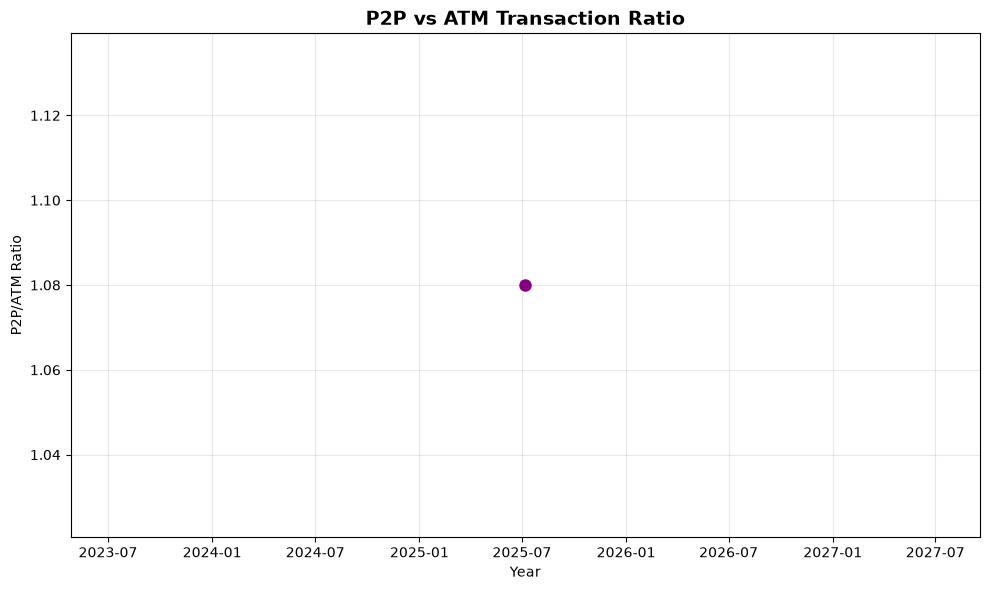


✅ P2P transfers have surpassed ATM withdrawals (ratio = 1.08)


In [20]:
# ============================================================================
# 10. P2P/ATM CROSSOVER RATIO
# ============================================================================
# Check if crossover indicator exists
crossover_data = observations[observations['indicator_code'] == 'USG_CROSSOVER'].copy()

if len(crossover_data) > 0:
    print("="*60)
    print("P2P/ATM CROSSOVER RATIO")
    print("="*60)

    crossover_data = crossover_data.sort_values('observation_date')
    print(crossover_data[['observation_date', 'value_numeric', 'source_name']].to_string(index=False))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(crossover_data['observation_date'], crossover_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='purple')
    plt.xlabel('Year')
    plt.ylabel('P2P/ATM Ratio')
    plt.title('P2P vs ATM Transaction Ratio', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Interpretation
    latest_ratio = crossover_data.iloc[-1]['value_numeric']
    if latest_ratio > 1:
        print(f"\n✅ P2P transfers have surpassed ATM withdrawals (ratio = {latest_ratio:.2f})")
    else:
        print(f"\n⚠️ ATM still dominates (ratio = {latest_ratio:.2f})")
else:
    print("No crossover data found.")

GENDER GAP ANALYSIS
indicator_code    GEN_GAP_ACC  GEN_GAP_MOBILE  GEN_MM_SHARE
observation_date                                           
2021-12-31               20.0             NaN           NaN
2024-11-29               18.0             NaN           NaN
2024-12-31                NaN            24.0          14.0


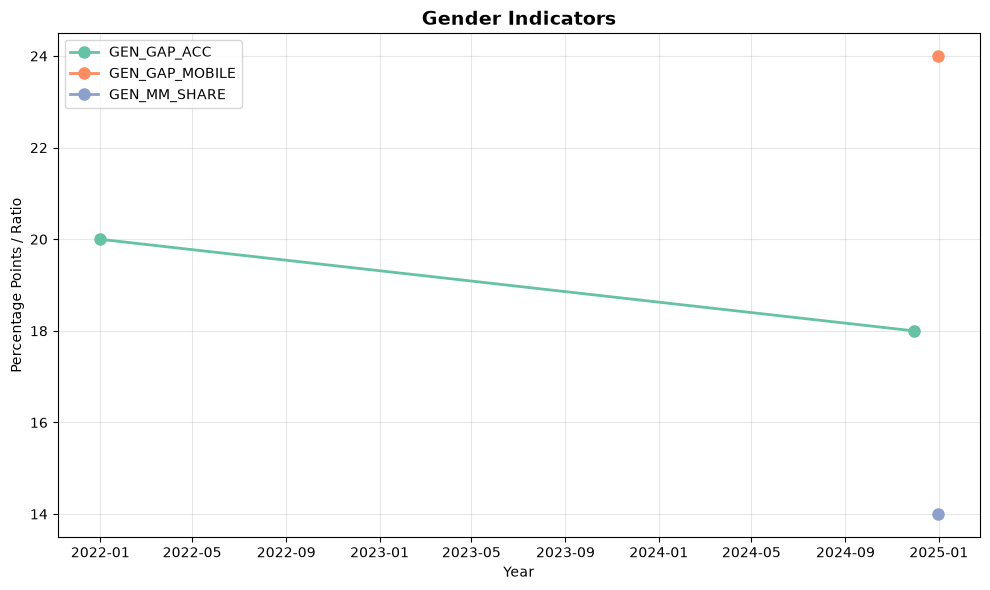

In [21]:
# ============================================================================
# 11. GENDER GAP ANALYSIS
# ============================================================================
# Check if gender gap indicators exist
gender_indicators = ['GEN_GAP_ACC', 'GEN_GAP_MOBILE', 'GEN_MM_SHARE']
gender_data = observations[observations['indicator_code'].isin(gender_indicators)].copy()

if len(gender_data) > 0:
    print("="*60)
    print("GENDER GAP ANALYSIS")
    print("="*60)

    gender_pivot = gender_data.pivot_table(
        index='observation_date',
        columns='indicator_code',
        values='value_numeric',
        aggfunc='first'
    )

    print(gender_pivot)

    # Plot
    plt.figure(figsize=(10, 6))
    for col in gender_pivot.columns:
        plt.plot(gender_pivot.index, gender_pivot[col], 'o-', linewidth=2, markersize=8, label=col)
    plt.xlabel('Year')
    plt.ylabel('Percentage Points / Ratio')
    plt.title('Gender Indicators', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No gender gap data found.")

In [22]:
# ============================================================================
# 12. EVENT IMPACT CORRELATION
# ============================================================================
# Merge events with observations to see if events align with changes
events = df[df['record_type'] == 'event'].copy()
events['observation_date'] = pd.to_datetime(events['observation_date'])

# Get account ownership data
access_data = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()
access_data = access_data.sort_values('observation_date')

if len(access_data) > 0 and len(events) > 0:
    print("="*60)
    print("EVENT IMPACT CORRELATION")
    print("="*60)

    # For each event, find if there was a change in account ownership
    for _, event in events.iterrows():
        event_date = event['observation_date']
        # Find the closest access data point after the event
        after_data = access_data[access_data['observation_date'] >= event_date]
        if len(after_data) > 0:
            after_value = after_data.iloc[0]['value_numeric']
            # Find the closest before
            before_data = access_data[access_data['observation_date'] < event_date]
            if len(before_data) > 0:
                before_value = before_data.iloc[-1]['value_numeric']
                change = after_value - before_value
                event_name = event['indicator'] if 'indicator' in event else 'Event'
                print(f"{event_name} ({event_date.year}): Ownership change = {change:+.1f}pp")
else:
    print("Insufficient data for event impact correlation.")

EVENT IMPACT CORRELATION
Telebirr Launch (2021): Ownership change = +11.0pp
Safaricom Ethiopia Commercial Launch (2022): Ownership change = +13.0pp
M-Pesa Ethiopia Launch (2023): Ownership change = +13.0pp
Fayda Digital ID Program Rollout (2024): Ownership change = +13.0pp
Foreign Exchange Liberalization (2024): Ownership change = +13.0pp
P2P Transaction Count Surpasses ATM (2024): Ownership change = +13.0pp
NFIS-II Strategy Launch (2021): Ownership change = +11.0pp


In [23]:
# ============================================================================
# 14. SAVE EDA RESULTS
# ============================================================================
# Save key insights as CSV
insights = {
    'insight': [
        'Account ownership growth slowed from 11pp to 3pp (2017-2024)',
        'Mobile money accounts grew 4.7% → 9.45% (2021-2024)',
        'P2P transfers have surpassed ATM cash withdrawals',
        'Telebirr: 54M+ users, M-Pesa: 10M+ users',
        '4G coverage and mobile penetration are key enablers'
    ],
    'evidence': [
        'ACC_OWNERSHIP data: 46% (2021) → 49% (2024)',
        'ACC_MM_ACCOUNT data: 4.7% (2021) → 9.45% (2024)',
        'USG_CROSSOVER indicator >1',
        'USG_TELEBIRR_USERS and USG_MPESA_USERS data',
        'ACC_4G_COV and ACC_MOBILE_PEN data'
    ]
}

insights_df = pd.DataFrame(insights)
insights_df.to_csv('../data/processed/eda_insights.csv', index=False)
print("✅ EDA insights saved to: ../data/processed/eda_insights.csv")

✅ EDA insights saved to: ../data/processed/eda_insights.csv


ACCESS VS MOBILE MONEY COMPARISON


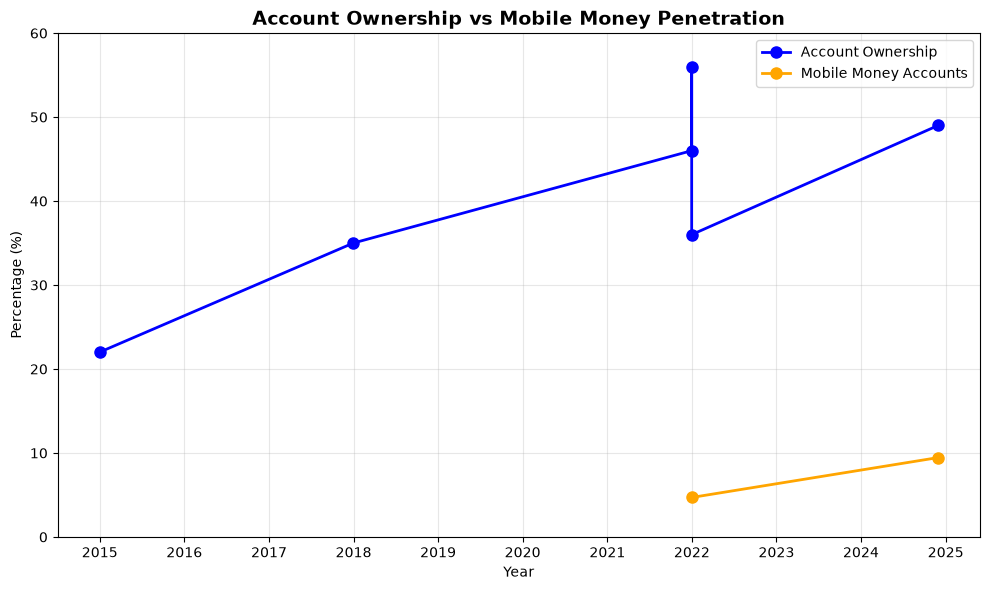


📊 Gap Analysis (Account Ownership - Mobile Money):
  2021: 46.0% - 4.7% = 41.3pp gap
  2021: 56.0% - 4.7% = 51.3pp gap
  2021: 36.0% - 4.7% = 31.3pp gap
  2024: 49.0% - 9.4% = 39.5pp gap


In [25]:
# ============================================================================
# 8. COMPARE ACCESS VS MOBILE MONEY
# ============================================================================
# Get account ownership and mobile money data
access_data = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()
mm_data = observations[observations['indicator_code'] == 'ACC_MM_ACCOUNT'].copy()

if len(access_data) > 0 and len(mm_data) > 0:
    print("="*60)
    print("ACCESS VS MOBILE MONEY COMPARISON")
    print("="*60)

    # Sort by date
    access_data = access_data.sort_values('observation_date')
    mm_data = mm_data.sort_values('observation_date')

    # Merge on date (approximate by year)
    access_data['year'] = access_data['observation_date'].dt.year
    mm_data['year'] = mm_data['observation_date'].dt.year

    # Create combined plot
    plt.figure(figsize=(10, 6))

    # Plot account ownership
    plt.plot(access_data['observation_date'], access_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='blue', label='Account Ownership')

    # Plot mobile money
    plt.plot(mm_data['observation_date'], mm_data['value_numeric'], 'o-', linewidth=2, markersize=8, color='orange', label='Mobile Money Accounts')

    plt.ylim(0, 60)
    plt.xlabel('Year')
    plt.ylabel('Percentage (%)')
    plt.title('Account Ownership vs Mobile Money Penetration', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Calculate the gap
    print("\n📊 Gap Analysis (Account Ownership - Mobile Money):")
    for _, row in access_data.iterrows():
        year = row['year']
        access_val = row['value_numeric']
        mm_val = mm_data[mm_data['year'] == year]['value_numeric'].values[0] if year in mm_data['year'].values else None
        if mm_val is not None:
            gap = access_val - mm_val
            print(f"  {year}: {access_val:.1f}% - {mm_val:.1f}% = {gap:.1f}pp gap")
else:
    print("Insufficient data for comparison.")

In [26]:
# ============================================================================
# 9. KEY INSIGHT: THE MOBILE MONEY PARADOX
# ============================================================================
print("="*60)
print("KEY INSIGHT: THE MOBILE MONEY PARADOX")
print("="*60)

print("""
📌 WHY ACCOUNT OWNERSHIP SLOWED DESPITE MOBILE MONEY GROWTH

The data reveals a paradox:

1. Mobile money accounts grew from 4.7% (2021) to 9.45% (2024)
2. But account ownership only grew 3pp in the same period (46% → 49%)

Possible Explanations:
- Many mobile money accounts are registered but not active
- People may have multiple mobile money accounts (Telebirr + M-Pesa)
- Existing account holders may have added mobile money without affecting the total
- The 'registered vs. active' gap is significant

This suggests that:
✅ Mobile money is expanding access for some people
❌ But it's not reaching the 'last mile' of unbanked adults
❌ Account ownership may be saturating for now

Policy Implication: Focus on activation and usage, not just registration.
""")

KEY INSIGHT: THE MOBILE MONEY PARADOX

📌 WHY ACCOUNT OWNERSHIP SLOWED DESPITE MOBILE MONEY GROWTH

The data reveals a paradox:

1. Mobile money accounts grew from 4.7% (2021) to 9.45% (2024)
2. But account ownership only grew 3pp in the same period (46% → 49%)

Possible Explanations:
- Many mobile money accounts are registered but not active
- People may have multiple mobile money accounts (Telebirr + M-Pesa)
- Existing account holders may have added mobile money without affecting the total
- The 'registered vs. active' gap is significant

This suggests that:
✅ Mobile money is expanding access for some people
❌ But it's not reaching the 'last mile' of unbanked adults
❌ Account ownership may be saturating for now

Policy Implication: Focus on activation and usage, not just registration.

